Download the data and relevant files:
M4 testSet.txtDownload M4 testSet.txt

M4 TrainingDataNegative.txtDownload M4 TrainingDataNegative.txt

M4 TrainingDataPositive.txtDownload M4 TrainingDataPositive.txt

Carry out your classification. This includes

- Conduct data preprocessing and provide an explanation of the relationship between features in the dataset (minimum 3 plots)
- Implement K-Nearest Neighbor (KNN) model. Provide Results, Accuracy Score of Prediction and Visualization.
- Implement SVM model. Provide Results, Accuracy Score of Prediction and Visualization.
Compare the results of KNN and SVM models.

In [3]:
# load data
with open("TrainingDataPositive.txt", "r", encoding="utf-8") as f:
    pos_reviews = f.readlines()

with open("TrainingDataNegative.txt", "r", encoding="utf-8") as f:
    neg_reviews = f.readlines()

with open("testSet.txt", "r", encoding="utf-8") as f:
    test_reviews = f.readlines()

**explanation**
- load all the files

In [6]:
import pandas as pd

training_data = pd.DataFrame({
    "review": pos_reviews + neg_reviews,
    "label": [1]*len(pos_reviews) + [0]*len(neg_reviews)
})
training_data.head()

,review,label
0,This paddle sport supply store is stocked to t...,1
1,This place is a veritable candy store for outd...,1
2,I've done quite a bit of canoeing and kayaking...,1
3,Great place to rent kayaks for a little bit of...,1
4,"Amazing selection of product, and very knowled...",1


**explanation**

- load data
- turn into dataframe and label positive reviews = 1, negative reviews = 0

In [7]:
# test data
test_labels = [1]*2989 + [0]*(len(test_reviews) - 2989)

test_data = pd.DataFrame({
    "review": test_reviews,
    "label": test_labels
})

test_data.head()

,review,label
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1


**explanation**

- in the instruction, it says In this file first 2989 reviews are positive and from 2990 to 4321 are negative.
- Separate the data based on the instruction and also labeled positive review to 1 and negative to 0

In [8]:
# preprocessing text
# remove punctuation and all lower case
import re

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

train_data["clean"] = train_data["review"].apply(preprocess)
test_data["clean"] = test_data["review"].apply(preprocess)

**explanation**
- created a function to remove all punctuations
- text.lower to make all letters lower case
- apply it to the data

In [9]:
# convert text to numbers
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_data["clean"])
X_test = vectorizer.transform(test_data["clean"])

y_train = train_data["label"]
y_test = test_data["label"]

**explanation**
- the models cannot understand text, so need to change to numbers
- max_features=5000 only keeps the 5000 most important words
- `.transform` is the part that transforms it

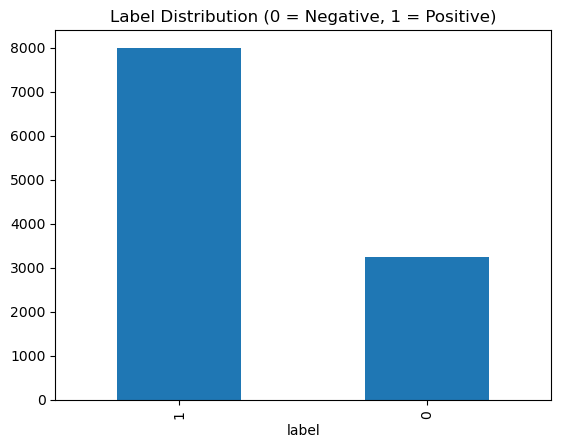

In [10]:
# plot 1
import matplotlib.pyplot as plt

train_data["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution (0 = Negative, 1 = Positive)")
plt.show()

**explanation**
- there are around 8000 positive reviews and 3000 negative reivews in my training dataset

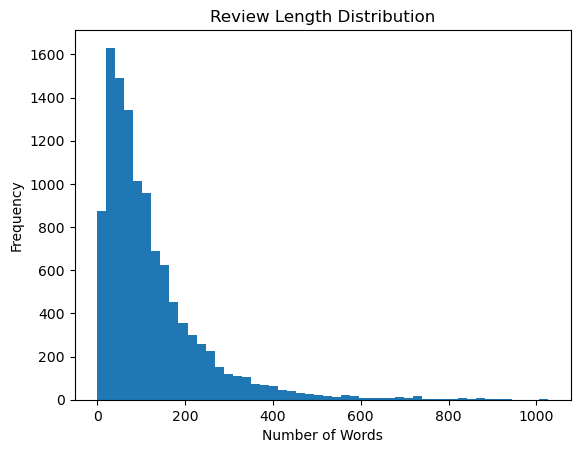

In [11]:
# plot 2
train_data["length"] = train_data["clean"].apply(lambda x: len(x.split()))

plt.hist(train_data["length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

**explanation**
- As the plot shows, most reviews are pretty short, within 0-200 words

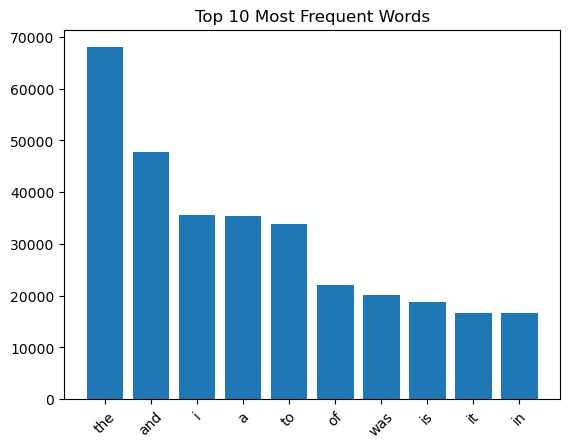

In [12]:
# plot 3
from collections import Counter

all_words = " ".join(train_data["clean"]).split()
common_words = Counter(all_words).most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

**explanation**
- the most frequent words shown are mostly common stopwords. I was not sure if this would impact the outcome, however ChatGPT had mentioned with the use of TfidfVectorizer, the more meaningful words would have a greater effect in the prediction ("ChatGPT", 5.2, 2026).

In [13]:
# KNN Model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.6965980097199722


**Explanation**

- Implement KNN model
- looking at 5 closest reviews (`k=5`)
- For example, if there are 3 positive reviews and 2 negative, then the prediction would be positive
- using accuracy_score to measure how many predictions are correct

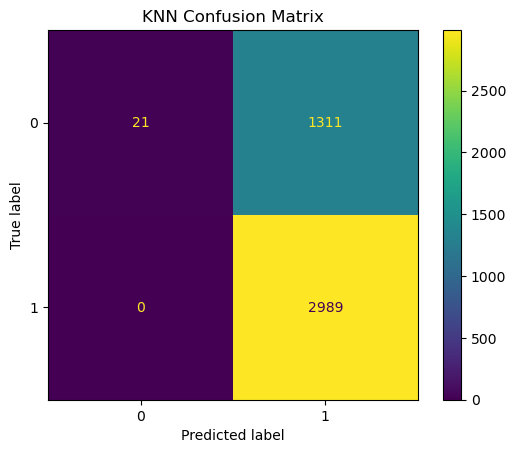

              precision    recall  f1-score   support

           0       1.00      0.02      0.03      1332
           1       0.70      1.00      0.82      2989

    accuracy                           0.70      4321
   macro avg       0.85      0.51      0.43      4321
weighted avg       0.79      0.70      0.58      4321



In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN Confusion Matrix")
plt.show()

# Full report
print(classification_report(y_test, y_pred_knn))

**explanation**

- the confusion matrix tells how well the model predicts each class
- The Matrix shows 4300 reviews as positive and only 21 negative reviews.
- The model is guessing positive most of the time, the dataset may be biased showing even with an accuracy score of around 0.70, the results still seems to be unstable

In [19]:
# SVM
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9532515621383939


**explanation**

- using SVM to find the best boundary between positive and negative reviews
- used a linear model (`kernel=linear`) for text data
- Shows a high accuracy score in the end

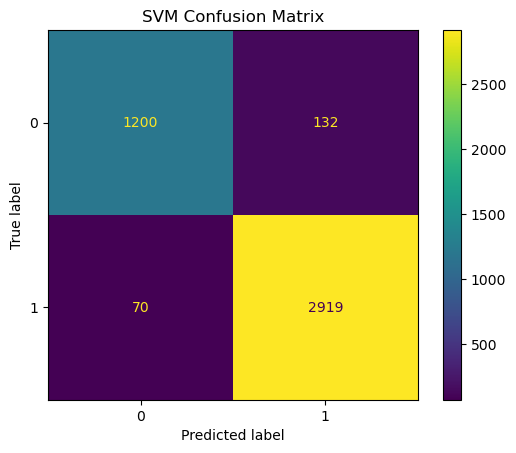

In [20]:
#viz
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM Confusion Matrix")
plt.show()

**explanation**

- as the confusion matrix shows, the result is very different than KNN
- There are 2919 True Positives and 1200 True negatives
- Both the False positive and negative values are small, meaning small errors

In [21]:
#resutls
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

KNN Accuracy: 0.6965980097199722
SVM Accuracy: 0.9532515621383939


**explanation**

- Result has shown SVM performs better than KNN for text classification
- SVM better separates the 2 classes, instead of relying on distances
- compared to KNN, SVM confusion matrix also shows a much betteer balance
- KNN failed to classify the negative reviews